# Imaging Performance Comparison (Flare)
This notebook loops over different noise levels and calibration errors to generate, corrupt, image, and compare solar flare datasets.

In [61]:
import fasr_solar_simul as fss
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from scipy.special import j1
from scipy.constants import c
import os
import glob
from casatasks import tclean, applycal, clearcal
from datetime import datetime
from pathlib import Path
from tqdm import tqdm
from astropy.time import Time
from sunpy import coordinates

# Speed of light in m/s
C_LIGHT = c
import matplotlib
%matplotlib inline

In [62]:
from importlib import reload

reload(fss)
target = 'flare'
figsubfolder = 'figs/'
model_dir = r'../fasr_sim/skymodels/eruptive_flare'

# Imaging Performance Comparison
looping over different noise levels and calibration errors to generate, corrupt, image, and compare

## Set up the simulation

In [76]:
# List of flare-test frequencies and imaging grids
freq_list = ['01.25GHz', '02.23GHz', '05.15GHz', '10.35GHz', '17.83GHz']
# imaging grid (try smaller cell for super-resolution experiments)
imsize = 800
cell = '0.5arcsec'
image_rms_corner_size = 100 ## in pixels (n by n) near the corner. This only applies to tclean images, not the model image.
vmax = 100.
# imsize = 2560
# cell = '1.0arcsec'
scales = [0, 6, 20]

imsizes = [800, 800, 800, 800, 1600]
cells = ['0.5arcsec', '0.5arcsec', '0.5arcsec', '0.5arcsec', '0.25arcsec']
# scales = [[0, 20, 60], 
#           [0, 10, 30], 
#           [0, 6, 20], 
#           [0, 10, 30], 
#           [0, 2, 5, 10]]
scales = [[0, 6, 15, 30], 
          [0, 4, 10, 20], 
          [0, 6, 20], 
          [0, 4, 10, 20], 
          [0, 2, 5, 10]]

# Config-dependent multiscale tuning is only needed at the two lowest frequencies,
# where the synthesized beam differs strongly between Hybrid 120 and Hybrid 120+10 remote.
scales_by_cfg = {
    '01.25GHz': {
        'fasr-a_random_spiral_hybrid_120.cfg': [0, 8, 20, 40],
        'fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg': [0, 4, 10, 20],
    },
    '02.23GHz': {
        'fasr-a_random_spiral_hybrid_120.cfg': [0, 6, 15, 30],
        'fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg': [0, 4, 10, 20],
    },
}

# List of configurations
project = 'FASR'
#config_files = ['fasr_Log_Spiral-168.cfg', 'fasr-a_random_spiral_hybrid_120.cfg']
config_files = ['fasr-a_random_spiral_hybrid_120.cfg']

## Antenna temperature noise levels
tsys_all = [300.]

## Define the fractional gain errors tuples: (phase and amplitude)
# 6 degrees (or 1.7% of phase error is equivalent to 10% of amplitude error )
cal_errors = [(0.1, 0.1)]

# Define channel width and integration time
channel_width_mhz = 24. # channel width in MHz
integration_time = 1. # Time per integration in seconds
duration = 1. # Total imaging duration in seconds

# Reference timestamp for the observation series
reftime_obj = fss.get_local_noon_utc(config_files[0], datetime(2017, 9, 10, 15, 45, 0))
reftime = reftime_obj.strftime('%Y-%m-%dT%H:%M:%S')  # flare simulation reference time
solar_radius_asec = coordinates.sun.angular_radius(reftime).value

# Flags to control overwriting existing data products
overwrite_ms   = False  # Overwrite measurement set?
overwrite_im   = False  # Overwrite image products?
overwrite_plot = True  # Overwrite existing plots?

weighting = 'uniform'
# Deconvolution algorithm choice
deconvolver = 'hogbom'
niter = 10000

deconvolver = 'multiscale'
niter = 10000
 
# Global plotting crop control used by all comparison plots
plot_crop_fraction = ((0.15, 0.9),(0.2,0.8))


# Centralized tclean phase center used by all imaging calls
## this phacenter is read from full disk image. 
## The ms may has some issue that hf.calc_phasecenter_from_solxy returns a phase center that is a few arcminutes off.
phasecenter_tclean = 'J2000 11h14m17s +4d44m48s' 
# phasecenter_tclean = ''


'get_local_noon_utc' completed at 2026-03-06 14:51:54; runtime: 0.06 seconds


In [77]:
scales

[[0, 6, 15, 30], [0, 4, 10, 20], [0, 6, 20], [0, 4, 10, 20], [0, 2, 5, 10]]

## Imaging Test: Hybrid 120 vs +10 Remote Antennas (2-10 km)
This section runs a small imaging test and compares:
- Base: `fasr-a_random_spiral_hybrid_120.cfg`
- Remote: `fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg`

It uses the same sky model and imaging parameters for both, so differences are driven by UV-coverage / weighting.

Processing flare imaging test at 01.25GHz
Total flux within primary beam used to calcuate the antenna temperature: 80.9 sfu
Tant (fasr-a_random_spiral_hybrid_120.cfg, 01.25GHz): 311K
80.8642
Calculate antenna temperature from total flux 80.8642 sfu incident on the dish
Total noise temperature (K): 6.105e+02 K
Estimated SEFD: 1.709e+06 Jy
Estimated natural weighting point source sensitivity sigma_na: 2.064e+00 Jy/beam
Estimated uniform weighting point source sensitivity sigma_un: 5.741e+00 Jy/beam
Estimated noise per baseline per channel per polarization per integration: 2.466e+02 Jy for 7140 baselines
Total flux within primary beam used to calcuate the antenna temperature: 80.9 sfu
Tant (fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg, 01.25GHz): 311K
80.8642
Calculate antenna temperature from total flux 80.8642 sfu incident on the dish
Total noise temperature (K): 6.105e+02 K
Estimated SEFD: 1.709e+06 Jy
Estimated natural weighting point source sensitivity sigma_na: 1.905e+00 Jy/

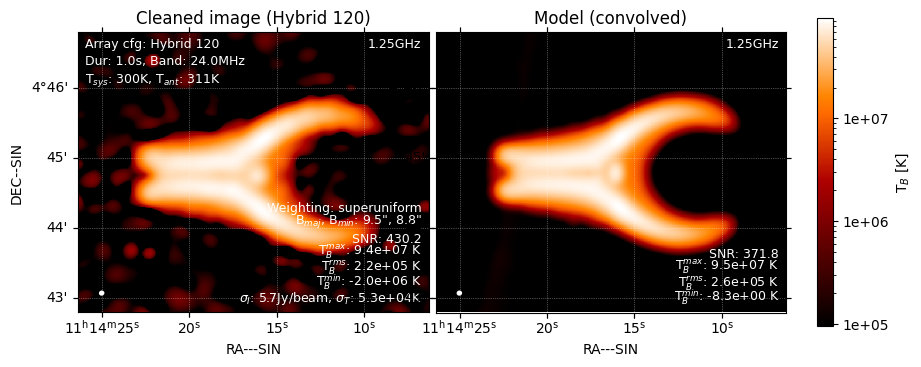

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_01.25GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale_vs_sep10_flare_cs_model.01.25GHz.I.im.jpg
Image1 map obstime: 2017-09-10T19:34:33.660669, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_01.25GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image: 1.476e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_01.25GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multi

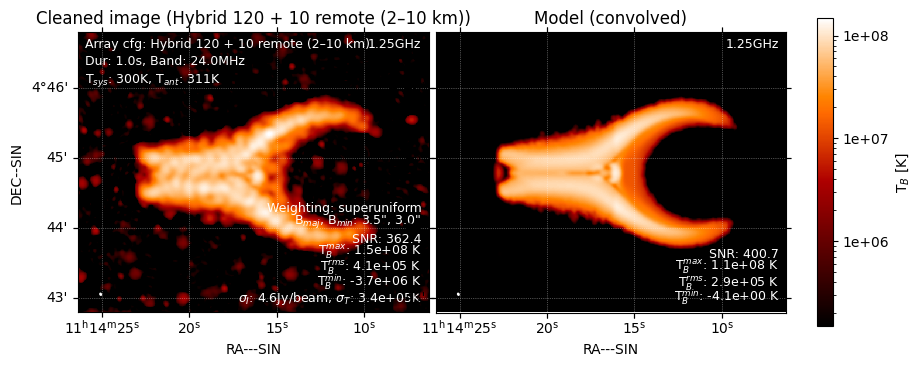

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_01.25GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale_vs_sep10_flare_cs_model.01.25GHz.I.im.jpg
Processing flare imaging test at 02.23GHz
Total flux within primary beam used to calcuate the antenna temperature: 654.2 sfu
Tant (fasr-a_random_spiral_hybrid_120.cfg, 02.23GHz): 2512K
654.1891
Calculate antenna temperature from total flux 654.1891 sfu incident on the dish
Total noise temperature (K): 2.812e+03 K
Estimated SEFD: 7.871e+06 Jy
Estimated natural weighting point source sensitivity sigma_na: 9.507e+00 Jy/beam
Estimated uniform weighting point source sensitivity sigma_un: 2.114e+01 Jy/beam
Estimated noise per baseline per channel per polarization per integration: 1.136e+03 Jy for 7140 baselines
Total flux within primary beam used to calcuate the antenna temperature: 654.2 sfu
Tant (fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg, 02.23GHz): 2512K
654.1891
Calculate antenna t

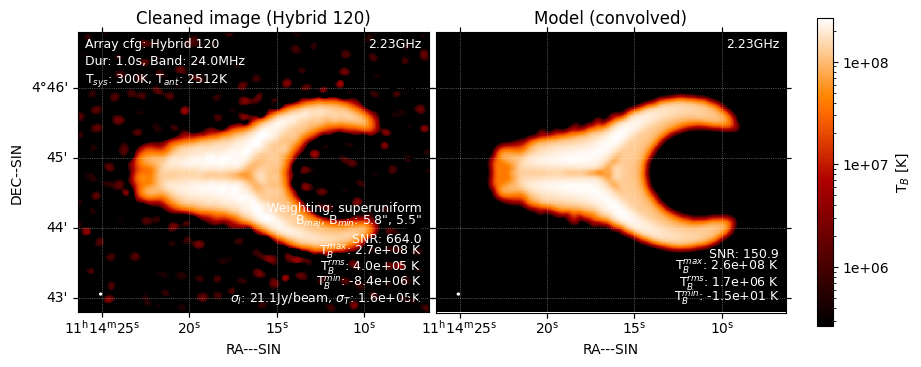

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_02.23GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale_vs_sep10_flare_cs_model.02.23GHz.I.im.jpg
Image1 map obstime: 2017-09-10T19:34:33.660669, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_02.23GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image: 3.021e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_02.23GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multi

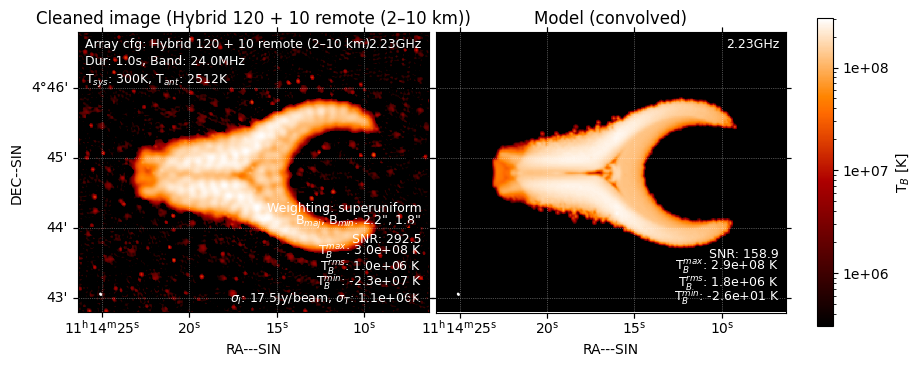

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_02.23GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale_vs_sep10_flare_cs_model.02.23GHz.I.im.jpg
Processing flare imaging test at 05.15GHz
Total flux within primary beam used to calcuate the antenna temperature: 1660.8 sfu
Tant (fasr-a_random_spiral_hybrid_120.cfg, 05.15GHz): 6377K
1660.84
Calculate antenna temperature from total flux 1660.84 sfu incident on the dish
Total noise temperature (K): 6.677e+03 K
Estimated SEFD: 1.869e+07 Jy
Estimated natural weighting point source sensitivity sigma_na: 2.257e+01 Jy/beam
Estimated uniform weighting point source sensitivity sigma_un: 3.823e+01 Jy/beam
Estimated noise per baseline per channel per polarization per integration: 2.698e+03 Jy for 7140 baselines
Total flux within primary beam used to calcuate the antenna temperature: 1660.8 sfu
Tant (fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg, 05.15GHz): 6377K
1660.84
Calculate antenna te

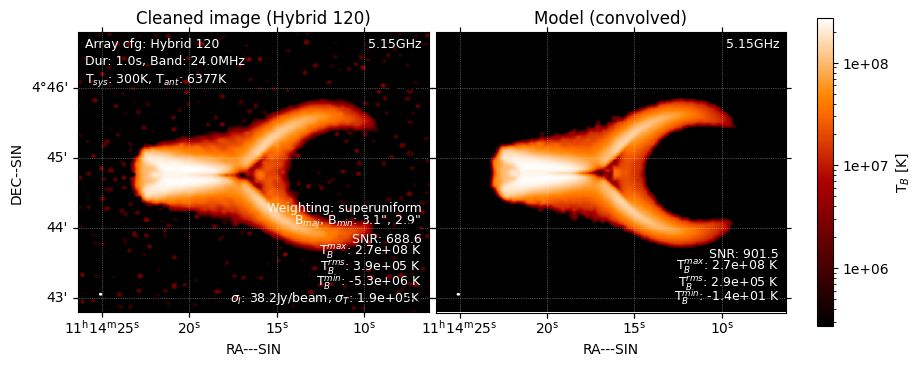

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I.im.jpg


2026-03-06 20:00:36	WARN	Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.947388 arcsec which is less than the pixel diagonal length of 1.69706 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size


Image1 map obstime: 2017-09-10T19:34:33.660669, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image: 2.880e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image (off-disk/border): 1.102e+06 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 3.527e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 3.921e+05 K
Plotting both pan

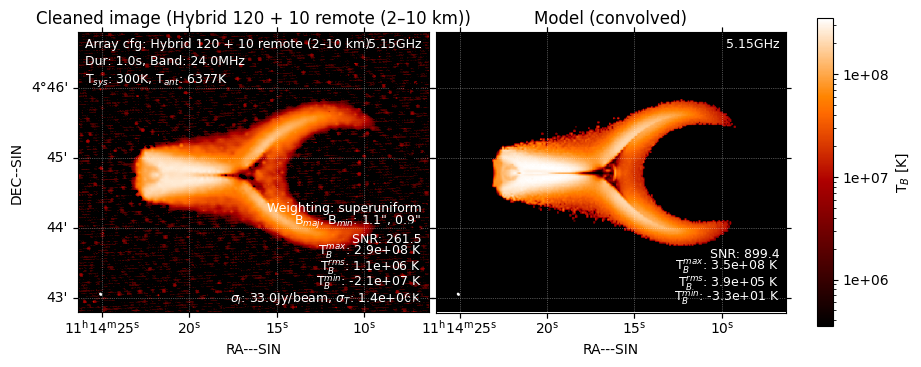

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I.im.jpg
Processing flare imaging test at 10.35GHz
Total flux within primary beam used to calcuate the antenna temperature: 1626.6 sfu
Tant (fasr-a_random_spiral_hybrid_120.cfg, 10.35GHz): 6246K
1626.5923
Calculate antenna temperature from total flux 1626.5923 sfu incident on the dish
Total noise temperature (K): 6.546e+03 K
Estimated SEFD: 1.832e+07 Jy
Estimated natural weighting point source sensitivity sigma_na: 2.213e+01 Jy/beam
Estimated uniform weighting point source sensitivity sigma_un: 3.054e+01 Jy/beam
Estimated noise per baseline per channel per polarization per integration: 2.645e+03 Jy for 7140 baselines
Total flux within primary beam used to calcuate the antenna temperature: 1626.6 sfu
Tant (fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg, 10.35GHz): 6246K
1626.5923
Calculate ante

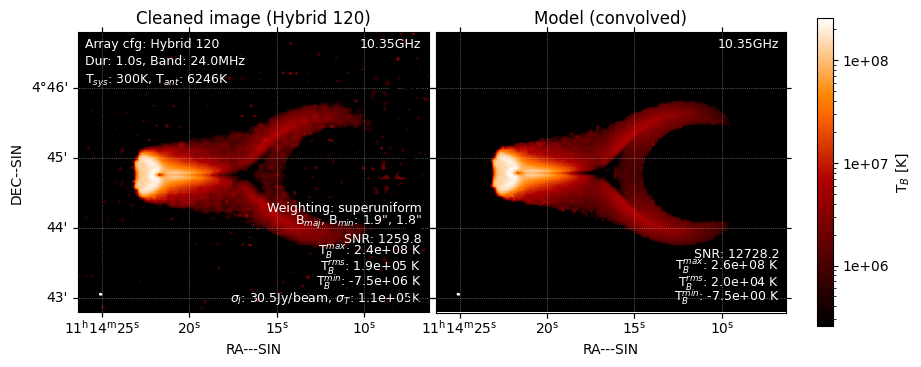

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_10.35GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale_vs_sep10_flare_cs_model.10.35GHz.I.im.jpg


2026-03-06 20:00:41	WARN	Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 1.27231 arcsec which is less than the pixel diagonal length of 1.69706 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size


Image1 map obstime: 2017-09-10T19:34:33.660669, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_10.35GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image: 2.477e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_10.35GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image (off-disk/border): 2.670e+05 K
Peak of sep10_flare_cs_model.10.35GHz.I.im: 2.702e+08 K
rms of sep10_flare_cs_model.10.35GHz.I.im (off-disk): 2.122e+04 K
Plotting both pan

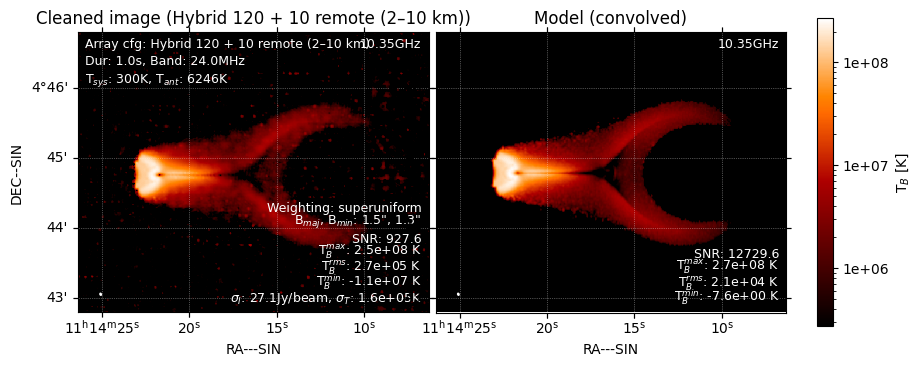

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_10.35GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale_vs_sep10_flare_cs_model.10.35GHz.I.im.jpg
Processing flare imaging test at 17.83GHz
Total flux within primary beam used to calcuate the antenna temperature: 2141.7 sfu
Tant (fasr-a_random_spiral_hybrid_120.cfg, 17.83GHz): 8224K
2141.667
Calculate antenna temperature from total flux 2141.667 sfu incident on the dish
Total noise temperature (K): 8.524e+03 K
Estimated SEFD: 2.386e+07 Jy
Estimated natural weighting point source sensitivity sigma_na: 2.882e+01 Jy/beam
Estimated uniform weighting point source sensitivity sigma_un: 3.511e+01 Jy/beam
Estimated noise per baseline per channel per polarization per integration: 3.444e+03 Jy for 7140 baselines
Total flux within primary beam used to calcuate the antenna temperature: 2141.7 sfu
Tant (fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg, 17.83GHz): 8224K
2141.667
Calculate antenna

2026-03-06 20:00:43	WARN	Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 1.19161 arcsec which is less than the pixel diagonal length of 1.69706 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size


Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_17.83GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image: 1.863e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_17.83GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image (off-disk/border): 5.808e+04 K
Peak of sep10_flare_cs_model.17.83GHz.I.im: 2.401e+08 K
rms of sep10_flare_cs_model.17.83GHz.I.im (off-disk): 2.821e+03 K
Plotting both panels with shared vmin=2.393e+05 K, 

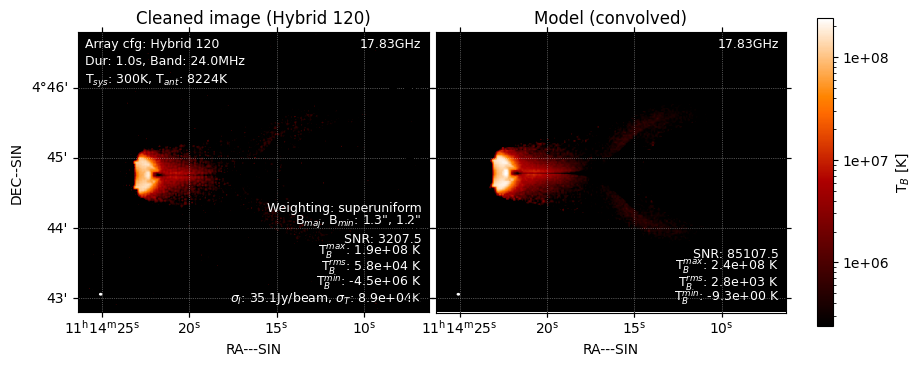

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_17.83GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale_vs_sep10_flare_cs_model.17.83GHz.I.im.jpg


2026-03-06 20:00:47	WARN	Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.90197 arcsec which is less than the pixel diagonal length of 1.69706 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size


Image1 map obstime: 2017-09-10T19:34:33.660669, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_17.83GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image: 1.943e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_17.83GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale.image (off-disk/border): 8.494e+04 K
Peak of sep10_flare_cs_model.17.83GHz.I.im: 3.399e+08 K
rms of sep10_flare_cs_model.17.83GHz.I.im (off-disk): 3.973e+03 K
Plotting both pan

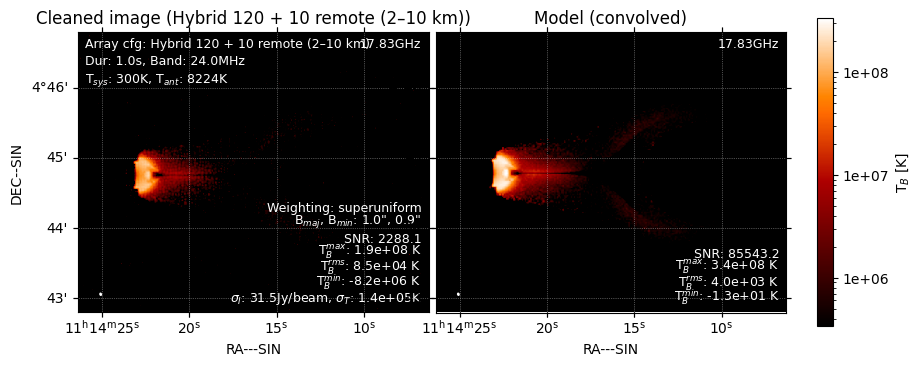

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_17.83GHz_20170910T19UT_dur1s_int1s_noise300K_superuniform_multiscale_vs_sep10_flare_cs_model.17.83GHz.I.im.jpg


In [79]:
phasecenter_tclean = globals().get('phasecenter_tclean', 'J2000 11h14m13.36s +30d04m44s')
reload(fss)
import os
import sys
_suncasa_src = os.path.expanduser('~/Dropbox/PycharmProjects/suncasa/suncasa-src')
if _suncasa_src not in sys.path:
    sys.path.append(_suncasa_src)
from suncasa.utils import helioimage2fits as hf
reload(hf)

# --- Configs to compare ---
base_cfg = 'fasr-a_random_spiral_hybrid_120.cfg'
remote_cfg = 'fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg'

# noise / integration
tsys = 300.
channel_width_mhz = 24.
integration_time = 1.
duration = 1.
image_rms_corner_size = 100 ## in pixels (n by n) near the corner. This only applies to tclean images, not the model image.
vmax = 100.

# flare-centered phasecenter in solar X/Y arcsec
flare_xycen = (1050, -140)

# calibration errors (quiet-Sun style default)
cal_errors = globals().get('cal_errors', [(0.1, 0.1)])
phaerr, amperr = cal_errors[0]

# baseline CASA timestamp
reftime_casa = Time(reftime).strftime('%Y/%m/%d/%H:%M:%S')

# Make sure output dirs exist
figdir = os.path.join(project, figsubfolder)
os.makedirs(figdir, exist_ok=True)
caltbdir = os.path.join(project, 'caltbs')
os.makedirs(caltbdir, exist_ok=True)

configs = [base_cfg, remote_cfg]
remote_cfg_base = os.path.basename(remote_cfg).replace('.cfg', '')
remote_parts = remote_cfg_base.split('_')
remote_count = next((p.replace('remote', '') for p in remote_parts if p.startswith('remote')), '?')
remote_range = next((p[1:] for p in remote_parts if p.startswith('r') and p.endswith('km') and '-' in p), '?-?km')
remote_range_label = remote_range.replace('km', ' km').replace('-', '–')
remote_label = f'Hybrid 120 + {remote_count} remote ({remote_range_label})'
labels = ['Hybrid 120', remote_label]
# weightings = ['natural', 'uniform']
weightings = ['superuniform']


def _ensure_default_calibration(msfile, overwrite=False):
    """Apply default phase/amplitude calibration errors to a derived MS copy."""
    phaerr_deg = np.rad2deg(phaerr)
    gaintable = [
        f'caltb_FASR_corrupt_{phaerr_deg:.0f}deg.ph',
        f'caltb_FASR_corrupt_{np.int_(amperr * 100)}pct.amp',
    ]
    if not os.path.exists(gaintable[0]) or not os.path.exists(gaintable[1]):
        gaintable = fss.generate_caltb(
            msfile,
            caltype=['ph', 'amp'],
            calerr=[phaerr, amperr],
            caltbdir=caltbdir,
        )
    calibrated_ms = msfile.replace('.ms', '_defaultcal.ms')
    if overwrite and os.path.exists(calibrated_ms):
        fss.remove_path(calibrated_ms)
    if not os.path.exists(calibrated_ms):
        shutil.copytree(msfile, calibrated_ms)
    clearcal(vis=calibrated_ms)
    applycal(vis=calibrated_ms, gaintable=gaintable, applymode='calonly', calwt=False)
    return calibrated_ms


# Optional: overwrite only +10 remote images (leave Hybrid 120 images untouched)
overwrite_remote_im = False  # set True to re-run only remote_cfg tclean images

for freqstr, imsize, cell_arcsec, scales_for_freq in zip(freq_list, imsizes, cells, scales):
    print(f'Processing flare imaging test at {freqstr}')
    solar_model = f'{model_dir}/sep10_flare_cs_model.{freqstr}.I.fits'
    _noise_terms_cache = {}

    def _noise_terms_for_cfg(config_file):
        key = (config_file, freqstr, imsize, cell_arcsec)
        if key in _noise_terms_cache:
            return _noise_terms_cache[key]

        antenna_params = np.genfromtxt(config_file, comments='#')
        dish_diameter = antenna_params[0, 3]
        uv_cell = 1. / (imsize * float(cell_arcsec.rstrip('arcsec')) / 206265.)
        total_flux = fss.calc_total_flux_on_dish(solar_model, dish_diameter=dish_diameter, freqghz=freqstr)
        tant = fss.total_flux_to_tant(total_flux, eta_a=0.6, dish_diameter=dish_diameter)
        print(f'Tant ({os.path.basename(config_file)}, {freqstr}): {tant:.0f}K')
        noisejy, sigma_na, sigma_un = fss.calc_noise(
            tsys, config_file, dish_diameter=dish_diameter,
            total_flux=total_flux, duration=duration,
            integration_time=integration_time,
            channel_width_mhz=channel_width_mhz,
            freqghz=freqstr, uv_cell=uv_cell,
        )
        sigma_jy = sigma_un / np.sqrt((duration / integration_time))
        terms = {
            'dish_diameter': dish_diameter,
            'uv_cell': uv_cell,
            'total_flux': total_flux,
            'tant': tant,
            'noisejy': noisejy,
            'sigma_na': sigma_na,
            'sigma_un': sigma_un,
            'sigma_jy': sigma_jy,
        }
        _noise_terms_cache[key] = terms
        return terms

    for weighting in weightings:
        ims = []
        for config_file in configs:
            noise_terms = _noise_terms_for_cfg(config_file)
            scales_this_cfg = scales_by_cfg.get(freqstr, {}).get(os.path.basename(config_file), scales_for_freq)
            msname = fss.make_msname(project, target, freqstr, Time(reftime).datetime, duration, integration_time, config_file, tsys)
            msfile = f'{msname}.ms'

            if (not os.path.exists(msfile)) or overwrite_ms:
                if os.path.exists(msfile) and overwrite_ms:
                    os.system('rm -rf ' + msfile)
                print('Start generating ms:', msfile)
                msfile = fss.generate_ms(
                    config_file, solar_model, reftime_casa, freqstr,
                    integration_time=integration_time, duration=duration,
                    channel_width_mhz=channel_width_mhz,
                    msname=msfile, tsys=tsys, usehourangle=True,
                    uv_cell=noise_terms['uv_cell']
                )

            # Make an image name that includes cfg + weighting
            imname = f'{msname}_{weighting}_{deconvolver}'
            is_remote_cfg = (config_file == remote_cfg)
            overwrite_this_image = overwrite_im or (overwrite_remote_im and is_remote_cfg)
            if os.path.exists(f'{imname}.image') and overwrite_this_image:
                for j in ['.image', '.model', '.mask', '.pb', '.psf', '.residual', '.sumwt']:
                    os.system(f'rm -rf {imname}{j}')

            if not os.path.exists(f'{imname}.image'):
                print('Imaging:', imname)
                calibrated_msfile = _ensure_default_calibration(msfile, overwrite=overwrite_ms)
                tclean(
                    vis=calibrated_msfile, imagename=imname,
                    datacolumn='data',
                    specmode='mfs',
                    deconvolver=deconvolver, scales=scales_this_cfg,
                    gain=0.2, cycleniter=200, minpsffraction=0.1, pblimit=0.01,
                    imsize=imsize, cell=cell_arcsec,
                    phasecenter=phasecenter_tclean,
                    weighting=weighting,
                    niter=niter,
                    interactive=False
                )
                for j in ['.model', '.mask', '.pb', '.psf', '.residual', '.sumwt']:
                    os.system(f'rm -rf {imname}{j}')

            ims.append(imname + '.image')

        # Compare each config against the flare model with the shared plotting utility
        model_path = os.path.join(project, 'msfiles', target, os.path.basename(solar_model.replace('.fits', '.im')))
        image_meta_common = {
            'freq': freqstr,
            'tsys': f'{tsys:.0f}K',
            'cal_error': f'{np.rad2deg(phaerr):.0f}'+r'$^{\circ}$ Pha' + f' & {np.int_(amperr * 100)}% Amp',
            'duration': f'{duration}s',
            'bandwidth': f'{channel_width_mhz}MHz',
        }
        cfg_display_names = [os.path.basename(cfg) for cfg in configs]

        for idx_cfg, im_path in enumerate(ims):
            fig_compare, axs_compare = fss.plot_two_casa_images_with_convolution_sunpy(
                im_path,
                model_path,
                crop_fraction=globals().get('plot_crop_fraction', (0.0, 1.0)),
                reftime=reftime,
                figsize=(10, 4),
                image_meta={
                    **image_meta_common,
                    'title': [f'Cleaned image ({labels[idx_cfg]})', 'Model (convolved)'],
                    'array_config': cfg_display_names[idx_cfg],
                    'tant': f"{_noise_terms_for_cfg(configs[idx_cfg])['tant']:.0f}K",
                    'sigma_jy': f"{_noise_terms_for_cfg(configs[idx_cfg])['sigma_jy']:.1f}Jy/beam",
                    'imaging_weighting': weighting,
                },
                cmap='hinodexrt',
                vmax=vmax,
                vmin=0.1,
                conv_tag=f'.compare_{weighting}_{idx_cfg}',
                overwrite_conv=True,
                rms_mask_radius=1.2,
                image_rms_corner_size=image_rms_corner_size,
                coord_frame='radec',
                match_fov=True,
                align_model_time_to_image=True,
                north_up=False,
                apply_hpc_p_angle=False,
                anchor_model_wcs_to_image=True,
                use_reftime_for_hpc=True,
            )
            plt.show()

            figname = os.path.join(
                figdir,
                f"fig-{os.path.basename(im_path).replace('.image', '')}_vs_{os.path.basename(model_path)}.jpg"
            )
            if os.path.exists(figname) and overwrite_plot:
                os.system('rm -rf ' + figname)
            if not os.path.exists(figname):
                fig_compare.savefig(figname, dpi=200)
                print('Saved figure:', figname)


In [5]:
pwd

'/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul'

In [6]:
im_path,msfile,imname

('FASR/msfiles/flare/fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uniform_multiscale.image',
 'FASR/msfiles/flare/fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K.ms',
 'FASR/msfiles/flare/fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uniform_multiscale')

## Super-Resolution / Long-Baseline Emphasis Options
With only a small number of remote antennas, the very long baselines are sparse. Even `uniform` weighting may not emphasize them enough. Below are two practical approaches that can push resolution beyond what uniform weighting gives.

1) **UV-range split + combine**: image long baselines only (high-res) and short baselines only (low-res), then combine in the image domain (e.g., `feather`).
2) **Manual weight boost**: multiply the MS `WEIGHT` / `SIGMA` by a function of UV-distance to upweight long baselines more strongly than uniform weighting.

Notes:
- Both methods increase noise in the final image and can create ringing if the long-baseline PSF sidelobes are high.
- Multi-scale deconvolution and tighter clean masks help stability.


In [35]:
## Super-resolution products and diagnostics (cfg-driven, one cfg per call)
from importlib import reload
reload(fss)
import os
import numpy as np

freqstr = '05.15GHz'
vmax = 100
crop_fraction = (0.0, 1.0)
image_rms_corner_size = 20
# uvthr_klambda_list = [3.0, 5.0, 10.0, 15.0, 20.0, 30.0, 50.0]
uvthr_klambda_list = [10.0, 15.0, 20.0, 30.0]
boost_param_grid = [(10, 1.5), (10, 2.0), (20, 1.5), (20, 2.0), (30, 1.5), (30, 2.0)]
max_boost = 3.0
uv_density_bin_m = 10.0
superres_weighting_default = 'superuniform'
use_boost_restoringbeam = True
apply_default_calibration = globals().get('apply_default_calibration', True)
show_cal_error_text = globals().get('show_cal_error_text', False)

cal_errors = globals().get('cal_errors', [(0.1, 0.1)])
phaerr, amperr = cal_errors[0]
phasecenter_tclean = globals().get('phasecenter_tclean', 'J2000 11h14m13.36s +30d04m44s')

model_fits = globals().get('superres_model_fits', f'{model_dir}/sep10_flare_cs_model.{freqstr}.I.fits')
model_base = os.path.join(project, 'msfiles', target, os.path.basename(model_fits.replace('.fits', '.im')))
model_path = fss.resolve_casa_image_path(model_base)
if model_path is None or not os.path.exists(model_path):
    raise FileNotFoundError(f'Model image not found: {model_base}')

figdir = os.path.join(project, figsubfolder)
os.makedirs(figdir, exist_ok=True)
caltbdir = os.path.join(project, 'caltbs')
os.makedirs(caltbdir, exist_ok=True)

image_meta_common = {
    'freq': freqstr,
    'tsys': f'{tsys:.0f}K' if 'tsys' in globals() else None,
    'cal_error': f'{np.rad2deg(phaerr):.0f}' + r'$^{\circ}$ Pha' + f' & {np.int_(amperr * 100)}% Amp',
    'duration': f'{duration}s' if 'duration' in globals() else None,
    'bandwidth': f'{channel_width_mhz}MHz' if 'channel_width_mhz' in globals() else None,
}

_noise_terms_cache = {}

def run_superres_products(cfg_file, cfg_label=None, superres_option=None, deconvolver_override=None, weighting='superuniform'):
    """Run super-resolution products for one array cfg."""
    cfg_label_text = cfg_label if cfg_label is not None else fss.humanize_array_config_label(cfg_file)
    msname = fss.make_msname(project, target, freqstr, Time(reftime).datetime, duration, integration_time, cfg_file, tsys)
    msfile = msname + '.ms'

    if cfg_file not in _noise_terms_cache:
        _noise_terms_cache[cfg_file] = fss.calc_noise_terms_for_cfg(
            cfg_file,
            model_fits,
            freqstr,
            imsize,
            cell,
            tsys,
            duration,
            integration_time,
            channel_width_mhz,
        )
    noise_terms = _noise_terms_cache[cfg_file]

    overwrite_ms_local = bool(globals().get('overwrite_ms', False))
    if os.path.exists(msfile) and overwrite_ms_local:
        fss.remove_path(msfile)
    if not os.path.exists(msfile):
        print('Start generating ms:', msfile)
        reftime_casa_local = Time(reftime).strftime('%Y/%m/%d/%H:%M:%S')
        msfile = fss.generate_ms(
            cfg_file,
            model_fits,
            reftime_casa_local,
            freqstr,
            integration_time=integration_time,
            duration=duration,
            channel_width_mhz=channel_width_mhz,
            msname=msfile,
            tsys=tsys,
            usehourangle=True,
            uv_cell=noise_terms['uv_cell'],
        )

    if apply_default_calibration:
        calibrated_msfile = fss.ensure_default_calibration(
            msfile,
            phaerr,
            amperr,
            caltbdir=caltbdir,
            overwrite=overwrite_ms_local,
        )
    else:
        calibrated_msfile = msfile

    overwrite_images = bool(globals().get('overwrite_superres_im', False) or globals().get('overwrite_im', False))
    overwrite_boost_ms = bool(globals().get('overwrite_boost_ms', False))
    deconv_use = deconvolver if deconvolver_override is None else deconvolver_override
    weighting_use = str(weighting).strip().lower() if weighting is not None else superres_weighting_default
    if not weighting_use:
        weighting_use = superres_weighting_default

    valid_options = {'feather', 'boost'}
    if superres_option is None:
        selected = set(valid_options)
        selected_mode = False
    else:
        if isinstance(superres_option, str):
            selected = {s.strip().lower() for s in superres_option.split(',') if s.strip()}
        elif isinstance(superres_option, (list, tuple, set)):
            selected = {str(s).strip().lower() for s in superres_option if str(s).strip()}
        else:
            raise TypeError('superres_option must be None, str, list, tuple, or set')
        invalid = selected - valid_options
        if invalid:
            raise ValueError(f'Invalid superres_option value(s): {sorted(invalid)}; allowed: {sorted(valid_options)}')
        selected_mode = True

    def plot_product(image_path, title_left, conv_tag, suffix, extra_meta=None):
        meta = dict(image_meta_common)
        meta['title_left'] = title_left
        fss.plot_compare_casa_vs_model(
            image_path=image_path,
            model_path=model_path,
            cfg_label_text=cfg_label_text,
            noise_terms=noise_terms,
            image_meta_common=meta,
            reftime=reftime,
            crop_fraction=crop_fraction,
            figsize=(11, 4),
            cmap='hinodexrt',
            vmax=vmax,
            conv_tag=conv_tag,
            image_rms_corner_size=image_rms_corner_size,
            suffix=suffix,
            figdir=figdir,
            overwrite_plot=overwrite_plot,
            extra_meta=extra_meta,
            show_cal_error_text=show_cal_error_text,
        )

    if 'feather' in selected:
        split_products = {}
        for thr in uvthr_klambda_list:
            split_products[thr] = fss.ensure_split_feather(
                msfile=calibrated_msfile,
                msname=msname,
                uvthr_klambda=thr,
                cell=cell,
                deconvolver=deconv_use,
                scales=scales,
                imsize=imsize,
                phasecenter=phasecenter_tclean,
                niter=niter,
                overwrite_images=overwrite_images,
                weighting=weighting_use,
            )
            plot_product(split_products[thr]['short'], f'Cleaned image (uv<{thr}k, {cfg_label_text})', f'.short_uvlt{thr}k', f'short_uvlt{thr}k', {'imaging_weighting': weighting_use, 'uvrange': f'uv<{thr}k'})
            plot_product(split_products[thr]['long'], f'Cleaned image (uv>{thr}k, {cfg_label_text})', f'.long_uvgt{thr}k', f'long_uvgt{thr}k', {'imaging_weighting': weighting_use, 'uvrange': f'uv>{thr}k'})
            plot_product(split_products[thr]['feather'], f'Cleaned image (feathered, uvthr={thr}k, {cfg_label_text})', f'.feather_uvthr{thr}k', f'feather_uvthr{thr}k', {'imaging_weighting': f'feather ({weighting_use})'})

        fss.plot_uv_density_splits(msfile, cfg_label_text, uvthr_klambda_list, figdir, freqstr, bin_m=uv_density_bin_m)

    if 'boost' in selected:
        uvrange_min_kl = min(uvthr_klambda_list)
        for uv0, pwr in boost_param_grid:
            boost_path = fss.ensure_boost_image(
                msfile=calibrated_msfile,
                msname=msname,
                freqstr=freqstr,
                uv0_klambda=uv0,
                power=pwr,
                max_boost=max_boost,
                cell=cell,
                deconvolver=deconv_use,
                scales=scales,
                imsize=imsize,
                phasecenter=phasecenter_tclean,
                niter=niter,
                overwrite_ms=overwrite_boost_ms,
                overwrite_image=overwrite_images,
                uvrange_min_klambda=uvrange_min_kl,
                use_boost_restoringbeam=use_boost_restoringbeam,
                weighting=weighting_use,
            )
            plot_product(boost_path, f'Cleaned image (boosted uv0={uv0}k, p={pwr}, {cfg_label_text})', f'.boost_uv0{uv0}k_p{pwr}', f'boost_uv0{uv0}k_p{pwr}_max{max_boost}', {'imaging_weighting': f'boosted ({weighting_use})'})

        fss.plot_boost_weighting_curves(msfile, cfg_label_text, boost_param_grid, figdir, freqstr, max_boost, uvrange_min_klambda=uvrange_min_kl)


Total flux within primary beam used to calcuate the antenna temperature: 1660.8 sfu
1660.84
Calculate antenna temperature from total flux 1660.84 sfu incident on the dish
Total noise temperature (K): 6.677e+03 K
Estimated SEFD: 1.869e+07 Jy
Estimated natural weighting point source sensitivity sigma_na: 2.257e+01 Jy/beam
Estimated uniform weighting point source sensitivity sigma_un: 3.823e+01 Jy/beam
Estimated noise per baseline per channel per polarization per integration: 2.698e+03 Jy for 7140 baselines


2026-03-06 01:48:18	WARN	clearcal::calibrater::setvi(bool,bool)	Forcing use of OLD VisibilityIterator.


Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_wboost_uv010k_p1.5_image_multiscale.image: 2.771e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_wboost_uv010k_p1.5_image_multiscale.image (off-disk/border): 8.660e+05 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.648e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 2.937e+05 K
Plotting both panels with s

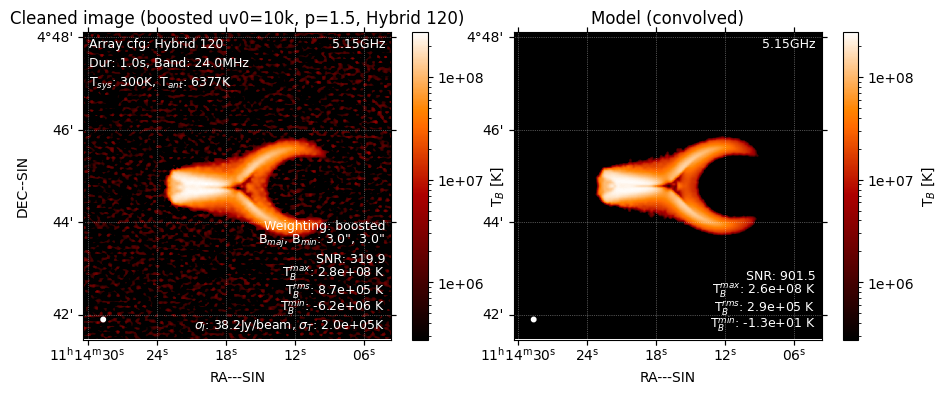

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_wboost_uv010k_p1.5_image_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_boost_uv010k_p1.5_max3.0_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_wboost_uv010k_p2.0_image_multiscale.image: 2.765e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise

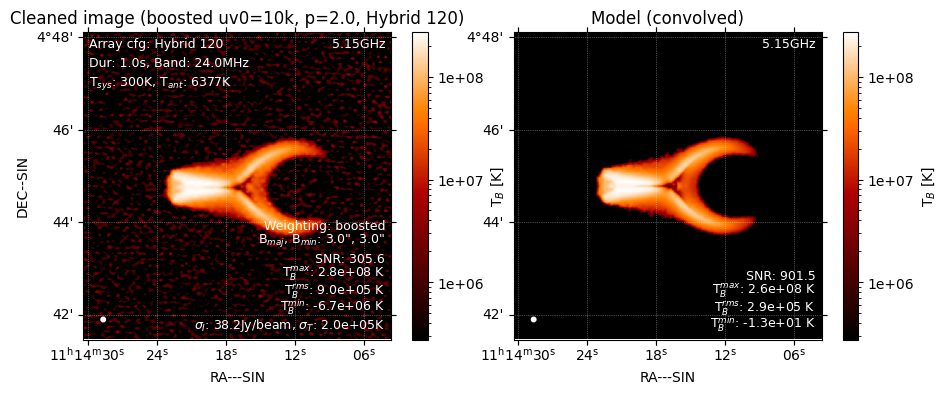

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_wboost_uv010k_p2.0_image_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_boost_uv010k_p2.0_max3.0_crop00-100.jpg


2026-03-06 01:48:25	WARN	Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 1.5 arcsec which is less than the pixel diagonal length of 1.69706 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size


Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_wboost_uv020k_p1.5_image_multiscale.image: 3.288e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_wboost_uv020k_p1.5_image_multiscale.image (off-disk/border): 3.287e+06 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.760e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 3.052e+05 K
Plotting both panels with s

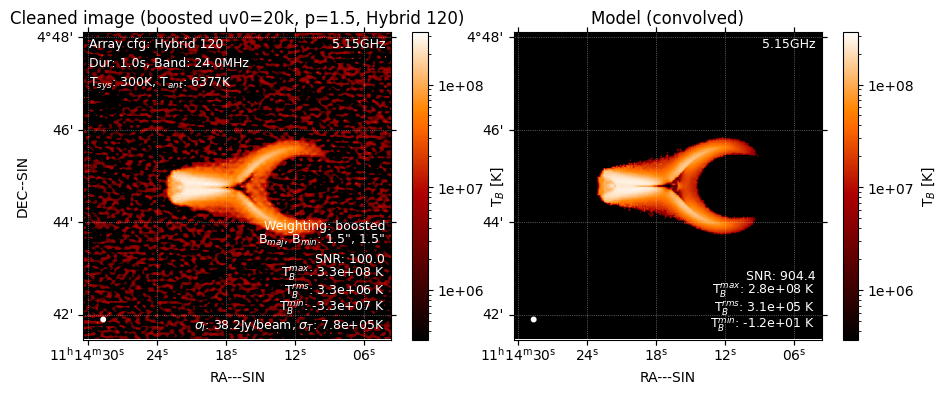

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_wboost_uv020k_p1.5_image_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_boost_uv020k_p1.5_max3.0_crop00-100.jpg


2026-03-06 01:48:27	WARN	Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 1.5 arcsec which is less than the pixel diagonal length of 1.69706 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size


Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_wboost_uv020k_p2.0_image_multiscale.image: 3.363e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_wboost_uv020k_p2.0_image_multiscale.image (off-disk/border): 2.974e+06 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.760e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 3.052e+05 K
Plotting both panels with s

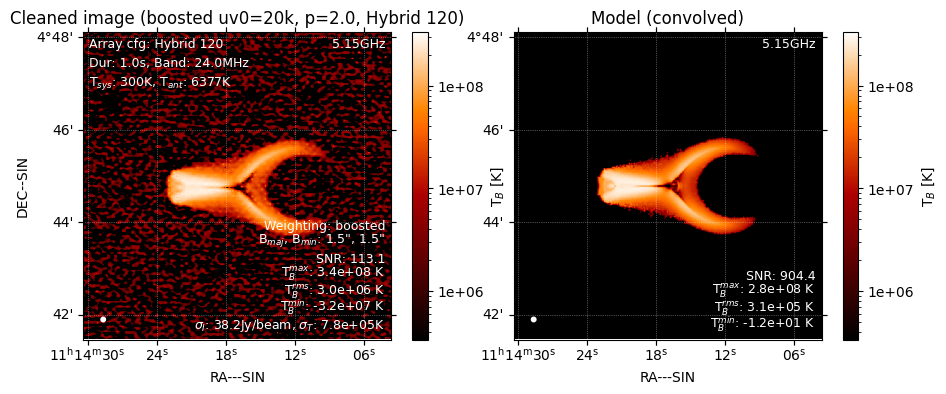

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_wboost_uv020k_p2.0_image_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_boost_uv020k_p2.0_max3.0_crop00-100.jpg


2026-03-06 01:48:30	WARN	Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 1 arcsec which is less than the pixel diagonal length of 1.69706 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size


Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_wboost_uv030k_p1.5_image_multiscale.image: 4.293e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_wboost_uv030k_p1.5_image_multiscale.image (off-disk/border): 6.259e+06 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 3.754e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 4.173e+05 K
Plotting both panels with s

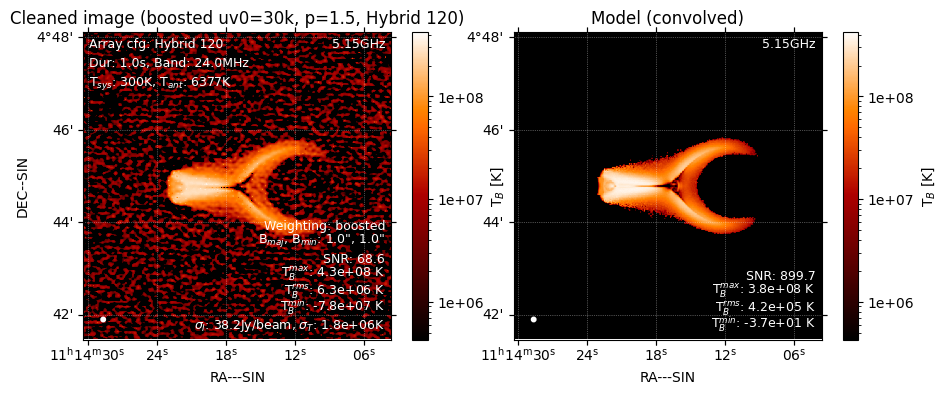

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_wboost_uv030k_p1.5_image_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_boost_uv030k_p1.5_max3.0_crop00-100.jpg


2026-03-06 01:48:34	WARN	Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 1 arcsec which is less than the pixel diagonal length of 1.69706 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size


Image1 map obstime: 2017-09-10T19:34:33.660694, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_wboost_uv030k_p2.0_image_multiscale.image: 4.108e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_wboost_uv030k_p2.0_image_multiscale.image (off-disk/border): 6.224e+06 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 3.754e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 4.173e+05 K
Plotting both panels with s

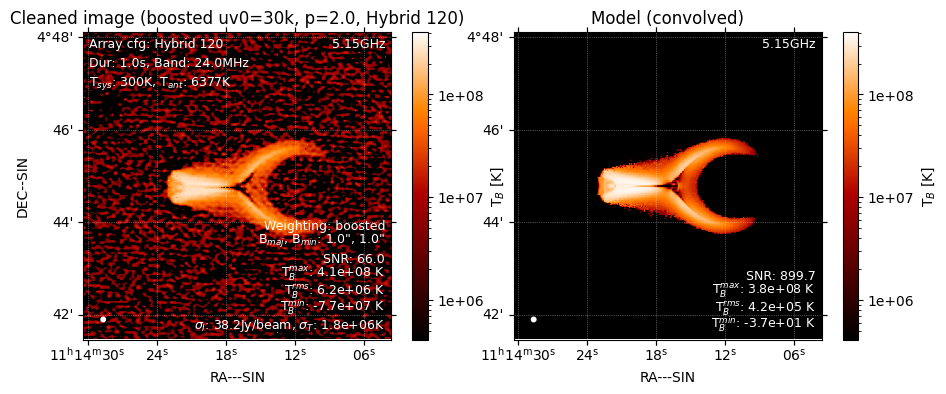

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K_wboost_uv030k_p2.0_image_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_boost_uv030k_p2.0_max3.0_crop00-100.jpg
Saved figure: FASR/figs/fig-boost_weighting_curves_fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise300K.jpg


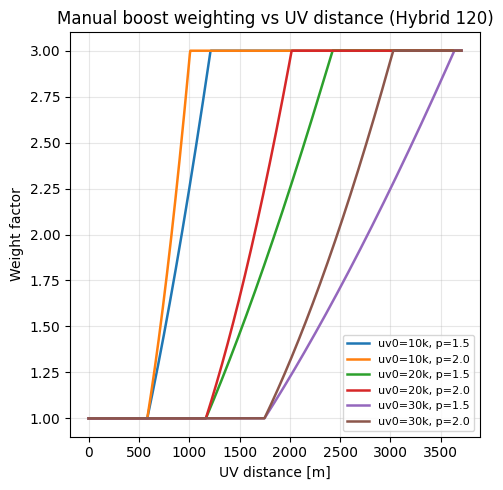

In [ ]:
run_superres_products(base_cfg, superres_option='boost', deconvolver_override='multiscale', weighting='superuniform')

Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt10.0k_0.5arcsec_uniform_multiscale.image: 2.387e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt10.0k_0.5arcsec_uniform_multiscale.image (off-disk/border): 5.905e+04 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.365e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 2.339e+05 K
Plotting both panel

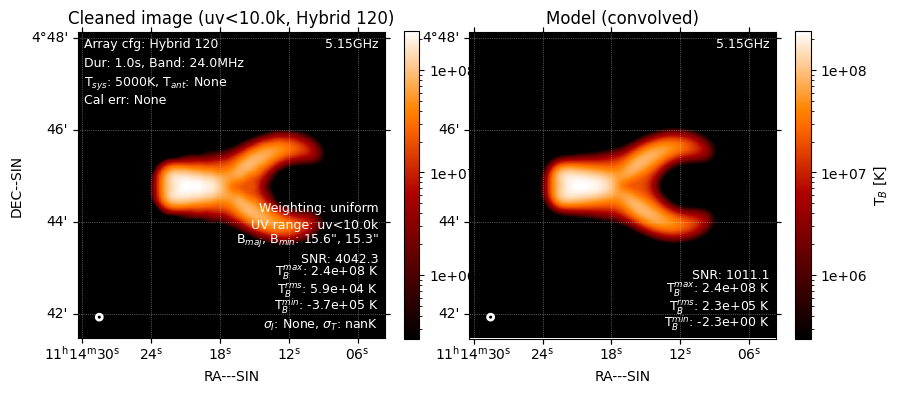

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt10.0k_0.5arcsec_uniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_short_uvlt10.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvgt10.0k_0.5arcsec_uniform_multiscale.image: 6.913e+07 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5

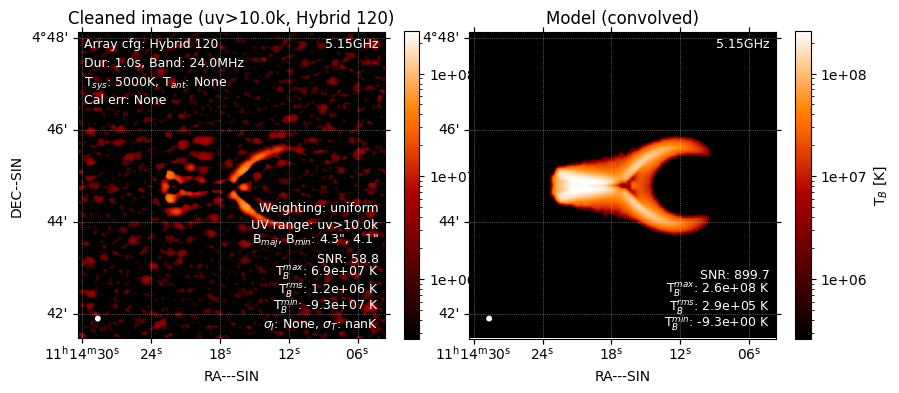

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvgt10.0k_0.5arcsec_uniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_long_uvgt10.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr10.0k_multiscale.image: 4.659e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feath

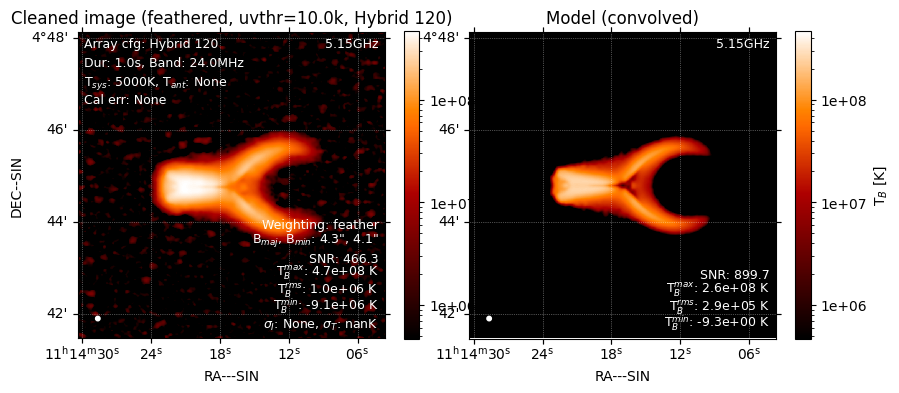

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr10.0k_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_feather_uvthr10.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt15.0k_0.5arcsec_uniform_multiscale.image: 2.471e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_u

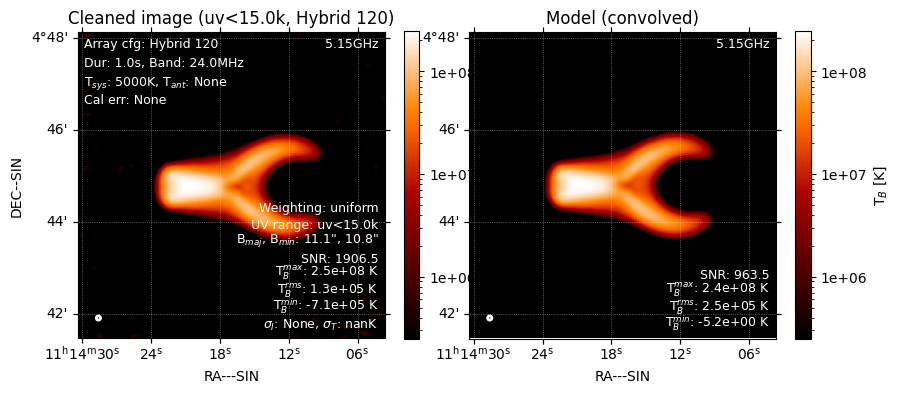

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt15.0k_0.5arcsec_uniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_short_uvlt15.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvgt15.0k_0.5arcsec_uniform_multiscale.image: 1.963e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5

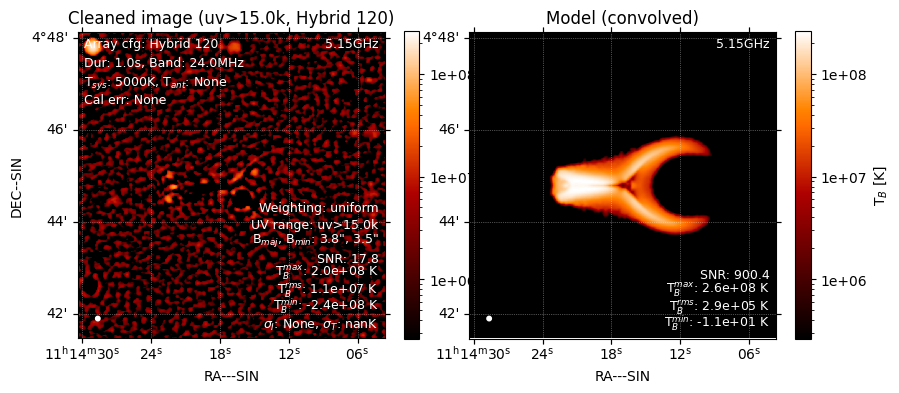

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvgt15.0k_0.5arcsec_uniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_long_uvgt15.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr15.0k_multiscale.image: 4.970e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feath

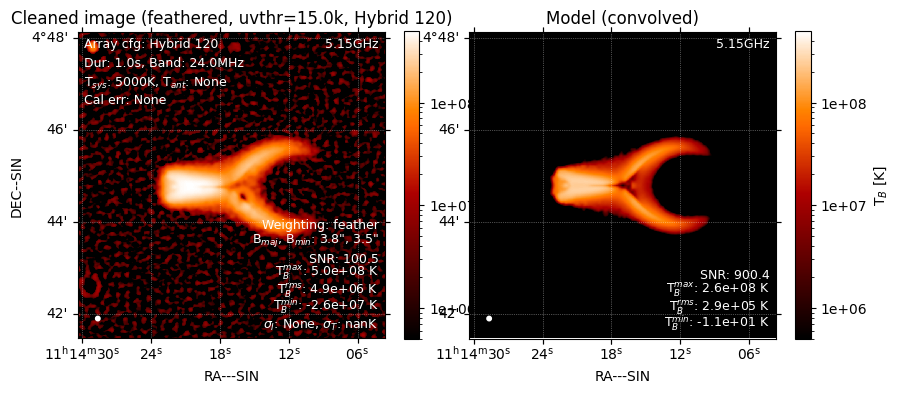

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr15.0k_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_feather_uvthr15.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt20.0k_0.5arcsec_uniform_multiscale.image: 2.464e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_u

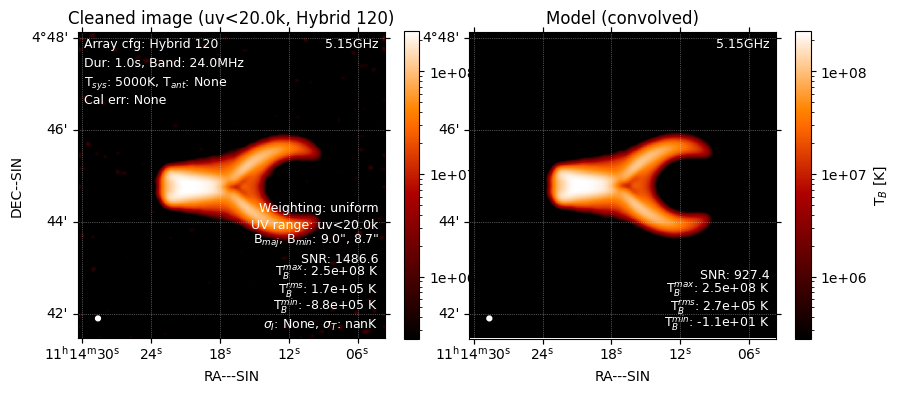

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt20.0k_0.5arcsec_uniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_short_uvlt20.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvgt20.0k_0.5arcsec_uniform_multiscale.image: 1.812e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5

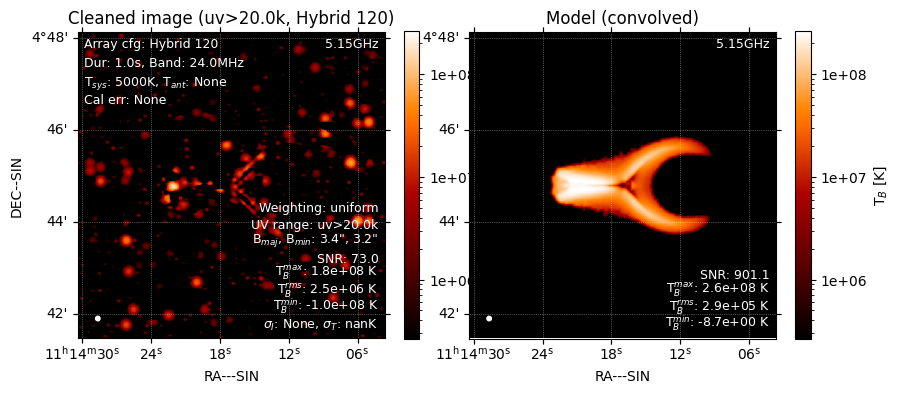

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvgt20.0k_0.5arcsec_uniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_long_uvgt20.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr20.0k_multiscale.image: 4.966e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feath

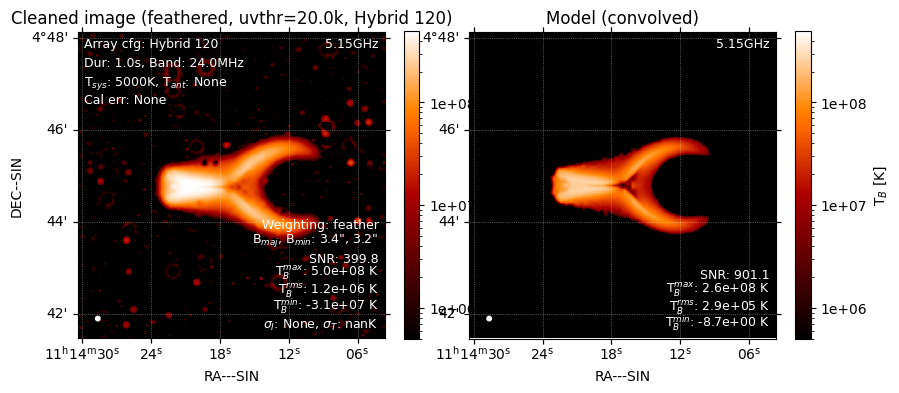

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr20.0k_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_feather_uvthr20.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt30.0k_0.5arcsec_uniform_multiscale.image: 2.516e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_u

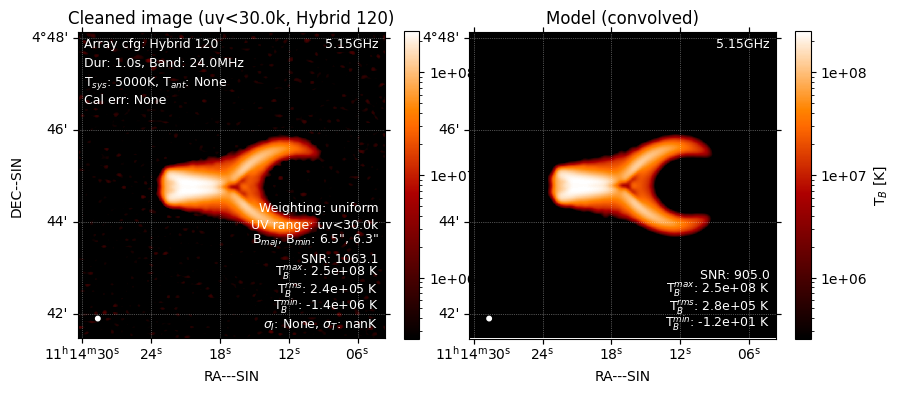

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt30.0k_0.5arcsec_uniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_short_uvlt30.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvgt30.0k_0.5arcsec_uniform_multiscale.image: 1.060e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5

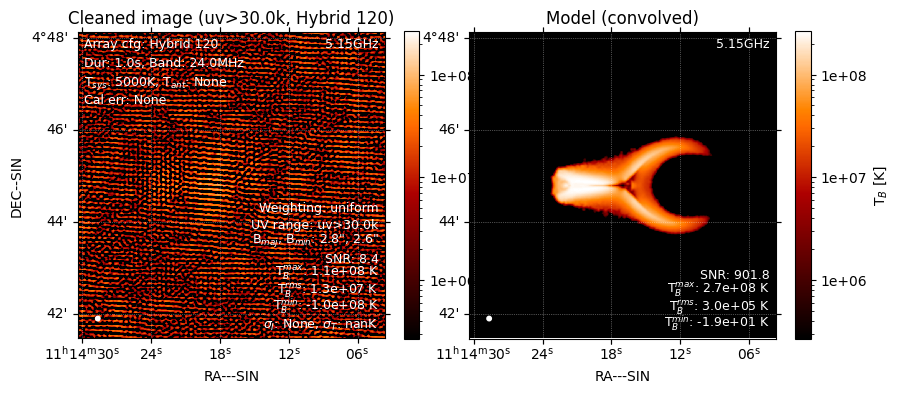

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvgt30.0k_0.5arcsec_uniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_long_uvgt30.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr30.0k_multiscale.image: 5.753e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feath

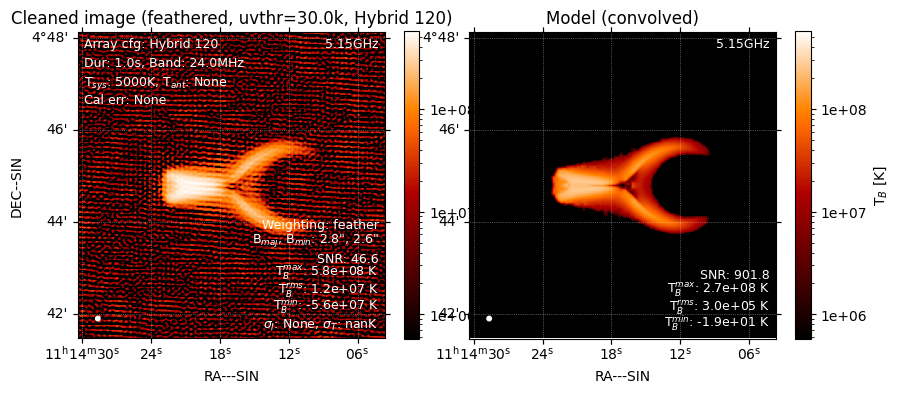

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr30.0k_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_feather_uvthr30.0k_crop00-100.jpg
Saved figure: FASR/figs/fig-uv_density_split_compare_fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K.jpg


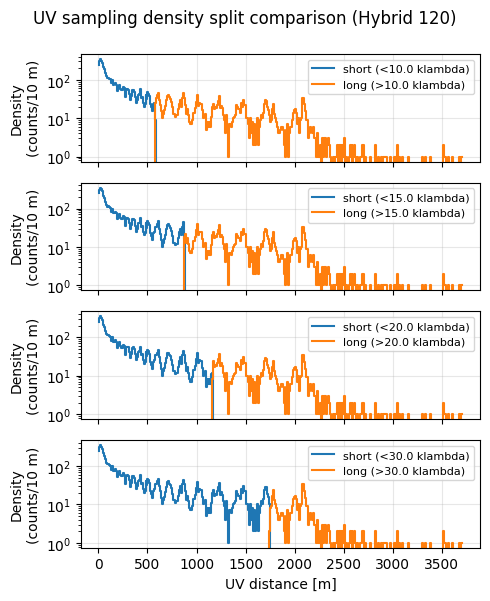

In [ ]:
run_superres_products(base_cfg, superres_option='feather', deconvolver_override='multiscale', weighting='superuniform')

2026-02-25 18:57:07	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Did not get the position of FASR from data repository
2026-02-25 18:57:07	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Please contact CASA to add it to the repository.
2026-02-25 18:57:07	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Using first antenna position as refence 
2026-02-25 18:57:33	WARN	SDAlgorithmMSClean::takeOneStep (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/c

Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_superuniform_multiscale.image: 2.683e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_superuniform_multiscale.image (corners): 1.546e+06 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.651e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 2.941e+05 K
Plotting both panels with shared vmin=2.683e+05 K, vmax=2

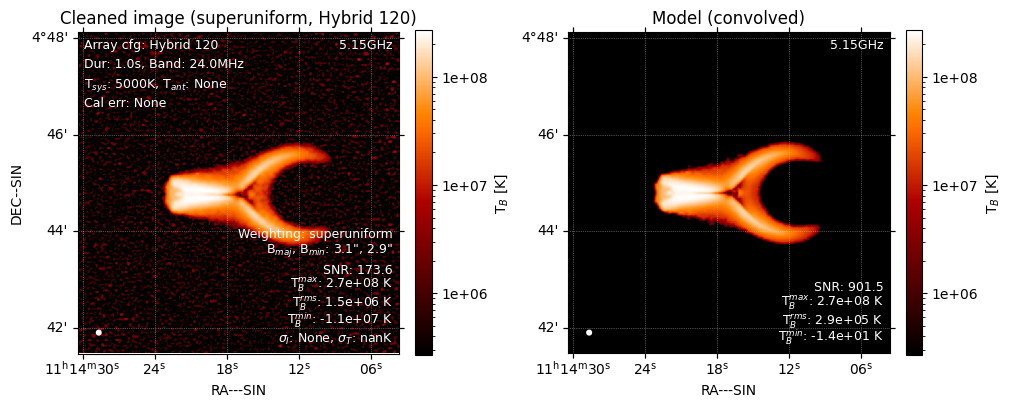

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_superuniform_crop00-100.jpg


In [ ]:
# run_superres_products(base_cfg, superres_option='superuniform', deconvolver_override='multiscale')

In [ ]:
# Super-resolution products for Hybrid 120 + 10 remote (one cfg per call)
run_superres_products(remote_cfg)

In [ ]:
print("Use variable-based paths in flare mode; hardcoded path removed")


Use variable-based paths in flare mode; hardcoded path removed


### make the figures

Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr10.0k_multiscale.image: 4.659e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr10.0k_multiscale.image (corners): 1.804e+06 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.760e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 3.065e+05 K
Plotting both panels with shared vmin=1.578e+

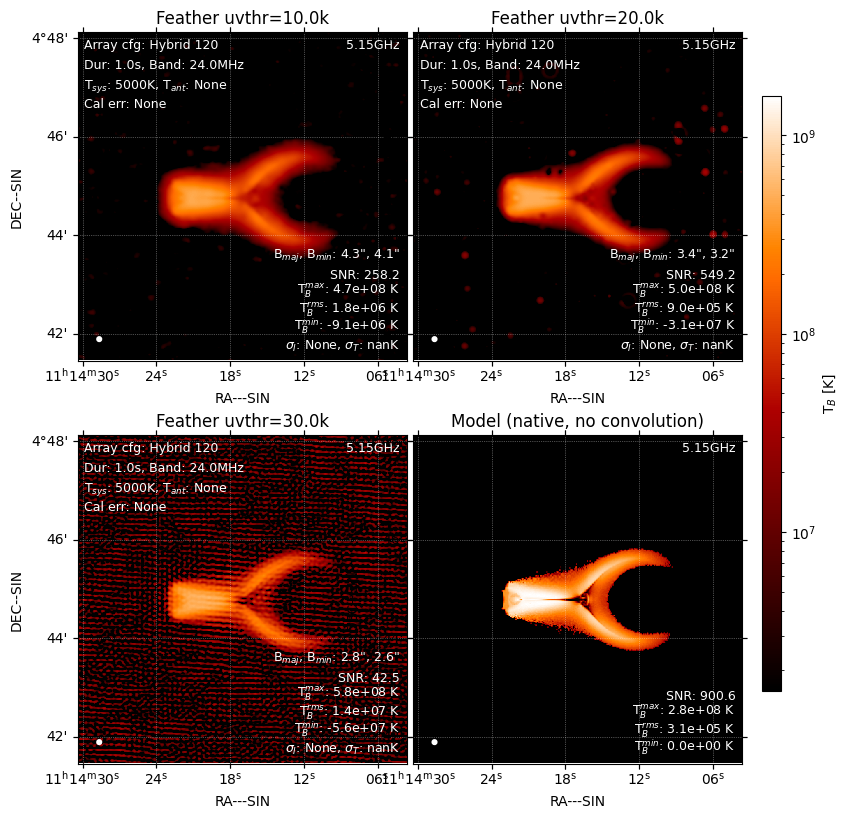

Saved figure: FASR/figs/fig-superres_feather_multiscale_3cases_vs_native_model.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv010k_p1.5_image_multiscale.image: 2.759e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv010k_p1.5_image_multiscale.image (corners): 9.024e+05 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.760e+08 K
rms of sep10_fla

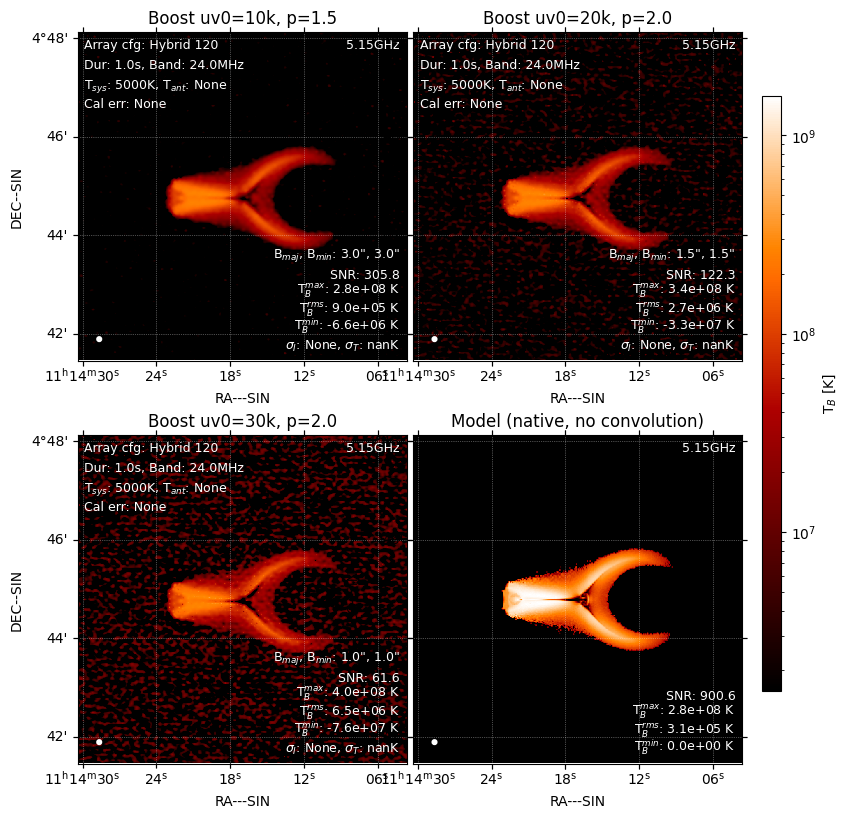

Saved figure: FASR/figs/fig-superres_boost_multiscale_3cases_vs_native_model.jpg


In [ ]:
# Manuscript figure assembly from existing products (no clean / no run_superres_products)
# This cell builds composite figures: 3 image results + 1 native model panel in one figure.

from importlib import reload
reload(fss)

model_image_native = _resolve_casa_image_path(model_base)
if model_image_native is None or not os.path.exists(model_image_native):
    raise FileNotFoundError(f'Native model image not found: {model_base}')

# ---- User inputs (three combos each) ----
feather_thresholds_kl = [10.0, 20.0, 30.0]
boost_params = [(10, 1.5), (20, 2.0), (30, 2.0)]
superres_deconvolver_for_manuscript = 'multiscale'

msname_base = _msname_for_cfg(base_cfg)
msfile_base = _msfile_for_cfg(base_cfg)

def _fmt_uv0(uv0):
    u = float(uv0)
    return f'{int(u)}' if abs(u - int(u)) < 1e-9 else str(u)

def _fmt_p(p):
    p = float(p)
    return f'{int(p)}' if abs(p - int(p)) < 1e-9 else str(p)

def _feather_image_path(thr):
    base = f'{msname_base}_feather_uvthr{thr}k_{superres_deconvolver_for_manuscript}'
    return base + '.image'

def _boost_image_path(uv0, power):
    uv_vals = [str(uv0)]
    p_vals = [str(power)]
    try:
        uvf = float(uv0)
        if uvf.is_integer():
            uv_vals.extend([str(int(uvf)), f'{uvf:.1f}'])
    except Exception:
        pass
    try:
        pf = float(power)
        if pf.is_integer():
            p_vals.extend([str(int(pf)), f'{pf:.1f}'])
    except Exception:
        pass

    uv_vals = list(dict.fromkeys(uv_vals))
    p_vals = list(dict.fromkeys(p_vals))

    candidates = []
    for uv_s in uv_vals:
        for p_s in p_vals:
            ms_boost = msfile_base.replace('.ms', f'_wboost_uv0{uv_s}k_p{p_s}.ms')
            candidates.append(ms_boost.replace('.ms', '') + f'_image_{superres_deconvolver_for_manuscript}.image')

    for cpath in candidates:
        if os.path.exists(cpath):
            return cpath
    return candidates[0]

feather_images = [_feather_image_path(t) for t in feather_thresholds_kl]
boost_images = [_boost_image_path(u, p) for u, p in boost_params]

missing_feather = [p for p in feather_images if not os.path.exists(p)]
missing_boost = [p for p in boost_images if not os.path.exists(p)]
if missing_feather:
    raise FileNotFoundError('Missing feather multiscale image(s):\n' + '\n'.join(missing_feather))
if missing_boost:
    raise FileNotFoundError(
        'Missing boost multiscale image(s):\n' + '\n'.join(missing_boost) +
        '\n\nUse existing multiscale boost outputs only, or generate them before running this cell.'
    )

feather_titles = [f'Feather uvthr={thr}k' for thr in feather_thresholds_kl]
boost_titles = [f'Boost uv0={u}k, p={p}' for u, p in boost_params]

fig_feather, _ = fss.plot_two_casa_images_with_convolution_sunpy(
    feather_images,
    model_image_native,
    crop_fraction=crop_fraction,
    reftime=reftime,
    figsize=(8, 8.5),
    panel_titles=feather_titles,
    image_meta={
        **image_meta_common,
        'title': ['Feathering parameter sweep', 'Model (native, no convolution)'],
        'array_config': 'Hybrid 120',
    },
    cmap='hinodexrt',
    vmin=0.1,
    vmax=vmax,
    conv_tag='.unused_native_model',
    overwrite_conv=False,
    convolve_model=False,
    rms_mask_radius=1.2,
    image_rms_corner_size=image_rms_corner_size,
    coord_frame='radec',
    match_fov=True,
    align_model_time_to_image=True,
    north_up=False,
    apply_hpc_p_angle=False,
    anchor_model_wcs_to_image=True,
    use_reftime_for_hpc=True,
)
plt.show()

figname_feather = os.path.join(figdir, 'fig-superres_feather_multiscale_3cases_vs_native_model.jpg')
if os.path.exists(figname_feather) and overwrite_plot:
    os.system('rm -rf ' + figname_feather)
if not os.path.exists(figname_feather):
    fig_feather.savefig(figname_feather, dpi=200)
    print('Saved figure:', figname_feather)

fig_boost, _ = fss.plot_two_casa_images_with_convolution_sunpy(
    boost_images,
    model_image_native,
    crop_fraction=crop_fraction,
    reftime=reftime,
    figsize=(8, 8.5),
    panel_titles=boost_titles,
    image_meta={
        **image_meta_common,
        'title': ['Boost parameter sweep', 'Model (native, no convolution)'],
        'array_config': 'Hybrid 120',
    },
    cmap='hinodexrt',
    vmin=0.1,
    vmax=vmax,
    conv_tag='.unused_native_model',
    overwrite_conv=False,
    convolve_model=False,
    rms_mask_radius=1.2,
    image_rms_corner_size=image_rms_corner_size,
    coord_frame='radec',
    match_fov=True,
    align_model_time_to_image=True,
    north_up=False,
    apply_hpc_p_angle=False,
    anchor_model_wcs_to_image=True,
    use_reftime_for_hpc=True,
)
plt.show()

figname_boost = os.path.join(figdir, 'fig-superres_boost_multiscale_3cases_vs_native_model.jpg')
if os.path.exists(figname_boost) and overwrite_plot:
    os.system('rm -rf ' + figname_boost)
if not os.path.exists(figname_boost):
    fig_boost.savefig(figname_boost, dpi=200)
    print('Saved figure:', figname_boost)


In [ ]:
## next step: add noise esitmate from quiet sun ipynb